# FigHaHbNetEmission — net Balmer (H$\alpha$, H$\beta$) emission per dex in radius

Net line power per dex in radius, $dL/d\ln r = 4\pi r^3\,j_{\rm net}$, with the Sobolev net
emissivity $j_{\rm net}=n_u A_{ul} h\nu\,\beta_{\rm esc}(\tau_{\rm Sob})$ (stimulated-emission
corrected). Top panel H$\alpha$ (3$\to$2), bottom H$\beta$ (4$\to$2). One curve per production run:
4 **marginally-unbound** (`1d_m*_dilute_redd`, orange) and 4 **photon-tired** $f=0.94$ ($\Gamma_0=1.21$)
(`repro/ptf_m*`, blue); colour = wind family, linestyle = $\dot M$. The
x-axis is $r/r_{\rm Edd}$; poorly-converged cells are drawn faded so the curves stay continuous.

In [1]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import wind_scales                     # one definition of r_sph (Mdot-dependent)
from scipy.integrate import cumulative_trapezoid as ctz

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
# NOTE: runs use matrix_pow ionization; photon sampling is user_bands (5 bands,
#   0.05-100 eV) for the mu family and wide for the pt family. The photon-tired family is
#   called pt_* here and in the paper (f=0.94 tiring fraction, Gamma_0=1.2128,
#   Owocki+2017 winds); its DATA still lives in repro/ptf_* on disk.
#   *** Do NOT repoint these paths at repro/pt_* -- those directories still exist and hold a
#   *** DIFFERENT, superseded Gamma_0=1.38 family. They would load silently and be wrong.
#   pt m10/m15 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
RUN_DIRS = {"mu_m2.5": "repro/mu_m2.5", "mu_m5": "repro/mu_m5",
                   "mu_m10": "repro/mu_m10", "mu_m15": "repro/mu_m15",
                   "pt_m2.5": "repro/ptf_m2.5", "pt_m5": "repro/ptf_m5",
                   "pt_m10": "repro/ptf_m10", "pt_m15": "repro/ptf_m15_n300"}
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

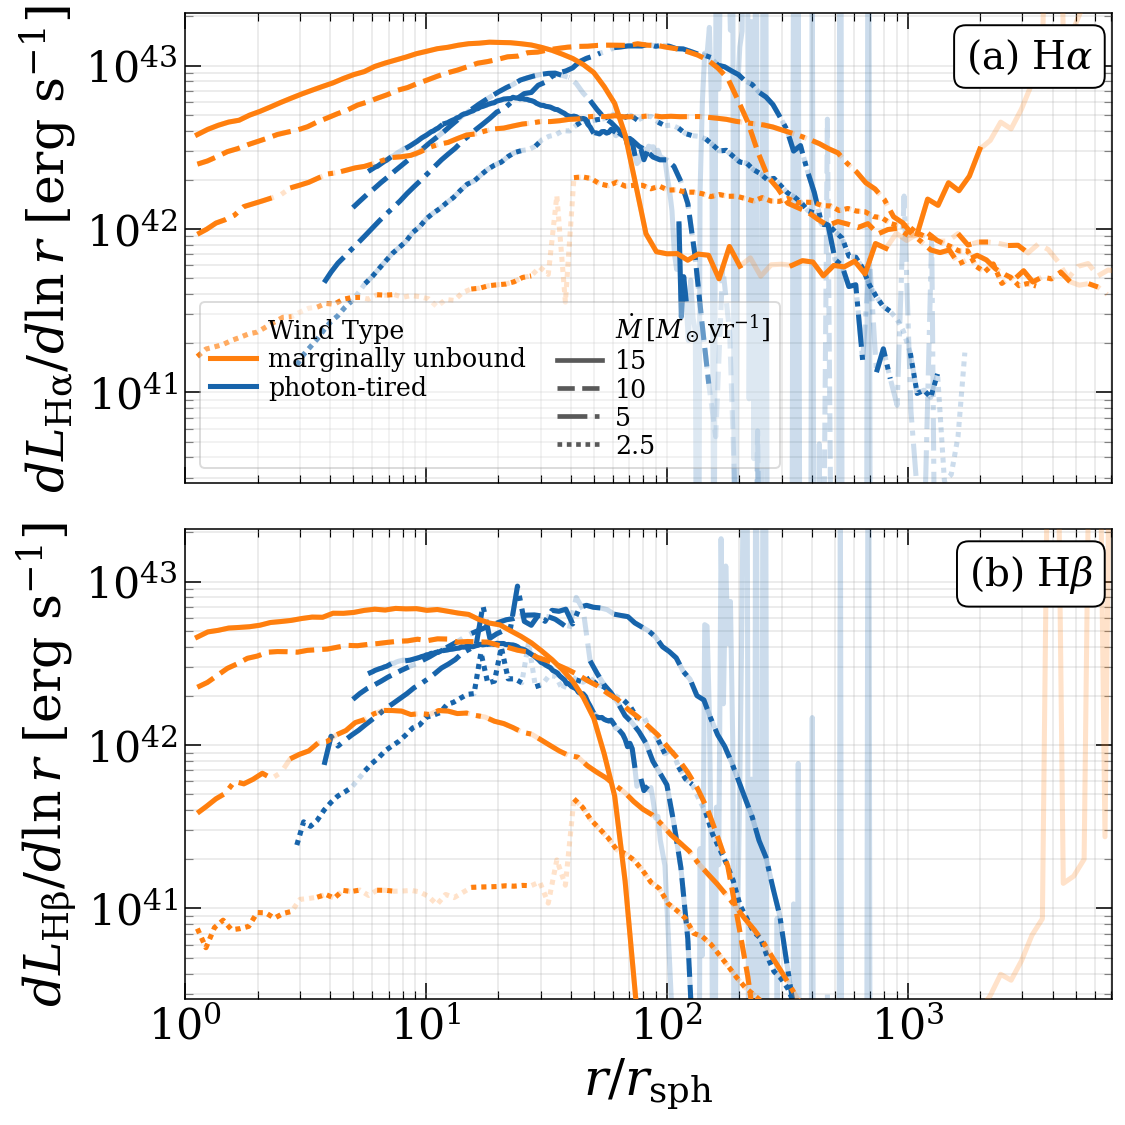

In [2]:
# ============================================================================
# FigHaHbNetEmission — net Balmer-line emission vs radius, stacked two-panel.
# Top: H-alpha net emission;  bottom: H-beta net emission.  One line per run
# (4 marginally-unbound + 4 photon-tired f=0.94 (Gamma_0=1.21)).  colour = wind family,
# linestyle = Mdot, x normalised to r_Edd, poorly-converged cells drawn FADED
# so the curves stay continuous.
# "Net emission" = net line power per dex in radius,  dL/dln r = 4 pi r^3 j_net,
# with j_net = n_u A_ul h*nu * beta_esc(tau_Sob)  (Sobolev escape, stim. corr.).
# ============================================================================
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

# ---- constants (CGS) ----
C=2.998e10; H=6.6261e-27; ME=9.109e-28; EE=4.803e-10
# radii normalised per-run by r_sph(Mdot); see wind_scales.py (the old flat 1.6e15 cm
# was r_sph only at Mdot=5). R_REF_PLOT sets the x-axis limits only.
R_REF_PLOT = float(wind_scales.r_sph(5.0))

# ---- Balmer line atomic data (lower level n=2; g_n = 2 n^2) ----
LINES={
 'Ha':dict(tex=r'H\alpha', lam=6562.80e-8, A=4.4101e7, f=0.64108, gl=8, gu=18, nu=3),
 'Hb':dict(tex=r'H\beta',  lam=4861.35e-8, A=8.4193e6, f=0.11938, gl=8, gu=32, nu=4),
}
for d in LINES.values(): d['nu0']=C/d['lam']

# ---- families / runs / styles (identical mapping to FigHeatCool) ----
MDOTS=['m2.5','m5','m10','m15']; MDNUM={'m2.5':2.5,'m5':5,'m10':10,'m15':15}   # last column = m15 runs (keys kept)
PT_COLOR=plt.cm.Blues(0.8); MB_COLOR='tab:orange'
LS_M={'m2.5':(0,(1,1)), 'm5':'-.', 'm10':'--', 'm15':'-'}   # dotted 2.5 ... solid 15
FADE=0.22
FAMILIES={
 'MU':dict(color=MB_COLOR, z=3, runs={md:f'mu_{md}' for md in MDOTS}),
 'PT':dict(color=PT_COLOR, z=2, runs={md:f'pt_{md}' for md in MDOTS}),
}
FONT_SCALE={'font.size':22,'axes.labelsize':26,'axes.titlesize':26,'xtick.labelsize':22,
            'ytick.labelsize':22,'legend.fontsize':18,'xtick.major.size':8,'xtick.minor.size':4,
            'ytick.major.size':8,'ytick.minor.size':4,'lines.linewidth':2.6}

def beta_sob(tau):               # Sobolev/escape probability (1-e^-tau)/tau -> 1 as tau->0
    t=np.maximum(tau,1e-30)
    return np.where(t>1e-6,(1-np.exp(-np.minimum(t,700.)))/t,1.0-0.5*t)

def load_netemis(rd, Mdot):      # -> r/r_sph(Mdot), {line: dL/dln r [erg/s]}, converged mask
    m=pd.read_csv(f'{rd}/outflow.master.txt',sep=r'\s+'); m=m[m['inwind']==0].reset_index(drop=True)
    L=pd.read_csv(f'{rd}/outflow.H_1.levden.txt',sep=r'\s+'); L=L[L['inwind']==0].reset_index(drop=True)
    n=min(len(m),len(L)); m=m.iloc[:n]; L=L.iloc[:n]
    r=m['r'].values; conv=m['converge'].values
    v=np.sqrt(m['v_x'].values**2+m['v_y'].values**2+m['v_z'].values**2)
    dvds=np.maximum(np.abs(np.gradient(v,r)),v/r)              # radial grad + transverse v/r floor
    nHI=L['ion_den'].values
    lev={i:nHI*L[f'lev{i}'].values for i in (2,3,4)}           # n_i = n_HI * frac level pop
    out={}
    for k,d in LINES.items():
        nl=lev[2]; nu=lev[d['nu']]; hnu=H*d['nu0']
        stim=1.0-(d['gl']*nu)/(d['gu']*np.maximum(nl,1e-99))   # stimulated-emission correction
        kappa0=(np.pi*EE**2/(ME*C))*d['f']*d['lam']
        tau=kappa0*nl*stim/dvds                                # radial Sobolev optical depth
        j_net=nu*d['A']*hnu*beta_sob(np.maximum(tau,0.0))      # net (escaping) emissivity
        out[k]=4*np.pi*r**3*j_net                              # dL/dln r
    o=np.argsort(r)
    return r[o]/float(wind_scales.r_sph(Mdot)), {k:out[k][o] for k in out}, (conv==0)[o]

def fplot(ax,x,y,good,**kw):     # faded underlay everywhere + crisp overlay on converged cells
    a=kw.pop('alpha',1.0)
    ax.plot(x,y,alpha=FADE*a,**kw)
    ax.plot(x,np.where(good,y,np.nan),alpha=a,**kw)

with plt.rc_context(FONT_SCALE):
    fig,(axA,axB)=plt.subplots(2,1,figsize=(8.5,8.5),sharex=True)
    PAN={'Ha':axA,'Hb':axB}; ymax=0.0
    for fk in ('PT','MU'):                                     # marginally unbound overlaid on top
        fam=FAMILIES[fk]
        for md in MDOTS:
            rd=run_path(fam['runs'][md])
            if not os.path.exists(f'{rd}/outflow.H_1.levden.txt'): continue
            x,dat,good=load_netemis(rd, MDNUM[md]); ls=LS_M[md]
            for k in LINES:
                fplot(PAN[k],x,dat[k],good,color=fam['color'],ls=ls,lw=2.6,zorder=fam['z'])
                if good.any(): ymax=max(ymax,np.nanmax(dat[k][good]))

    for k,ax in PAN.items():
        ax.set(xscale='log',yscale='log',
               ylabel=r'$dL_{\rm %s}/d\ln r$ [erg s$^{-1}$]'%LINES[k]['tex'],
               xlim=(1.0,1e19/R_REF_PLOT), ylim=(ymax*2e-3, ymax*1.5))
        ax.grid(alpha=0.3,which='both',zorder=0)
        ax.yaxis.set_minor_locator(LogLocator(base=10,subs=np.arange(2,10),numticks=100))
        ax.tick_params(axis='y',which='minor',length=4,color='gray')
    axB.set_xlabel(r'$r/r_{\rm sph}$')

    # 2-column legend (family colours | Mdot line styles), same layout as FigHeatCool_TeXi
    hdr=lambda label: Line2D([0],[0],color='none',lw=0,marker='',label=label)
    handles=[hdr('Wind Type'),
             Line2D([0],[0],color=MB_COLOR,lw=2.6,label='marginally unbound'),
             Line2D([0],[0],color=PT_COLOR,lw=2.6,label=r'photon-tired'),
             hdr(''),hdr(''),
             hdr(r'$\dot{M}\,[M_\odot\,\mathrm{yr}^{-1}]$'),
             *[Line2D([0],[0],color='0.35',lw=2.4,linestyle=LS_M[md],label=f'{MDNUM[md]:g}')
               for md in reversed(MDOTS)]]
    leg=axA.legend(handles=handles,ncol=2,loc='lower left',fontsize=13,framealpha=0.35,
                   columnspacing=1.2,handlelength=1.8,handletextpad=0.5,borderaxespad=0.6,labelspacing=0.12)
    leg.get_frame().set_edgecolor('0.6')

    axA.text(0.98,0.95,r'(a) H$\alpha$',transform=axA.transAxes,fontsize=20,ha='right',va='top',
             bbox=dict(facecolor='white',boxstyle='round'))
    axB.text(0.98,0.95,r'(b) H$\beta$',transform=axB.transAxes,fontsize=20,ha='right',va='top',
             bbox=dict(facecolor='white',boxstyle='round'))
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR,'FigHaHbNetEmission.pdf'))
    fig.savefig(os.path.join(FIG_DIR,'FigHaHbNetEmission.png'),dpi=300)
    plt.show()